<a href="https://colab.research.google.com/github/Gilf4/lab3_ml/blob/main/lab3_ex3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from tensorflow.keras.applications.resnet import preprocess_input

In [ ]:
dataset_hh, info_hh = tfds.load(
    'horses_or_humans',
    split='train + test',
    as_supervised=True,
    with_info=True
)

dataset_cd, info_cd = tfds.load(
    'cats_vs_dogs',
    split=f'train[:{len(dataset_hh)}]',
    as_supervised=True,
    with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/horses_or_humans/incomplete.OC13TB_3.0.0/horses_or_humans-train.tfrecord*.…

...

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UBZIDQ_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [ ]:
print(f"Horses vs Humans: {len(dataset_hh)}")
print(f"Cats vs Dogs: {len(dataset_cd)}")

Horses vs Humans: 1283
Cats vs Dogs: 1283


In [ ]:
IMG_SIZE = (224, 224)

def process_hh(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label

def process_cd(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = preprocess_input(image)
    return image, label + 2

dataset_hh = dataset_hh.map(process_hh)
dataset_cd = dataset_cd.map(process_cd)

In [ ]:
dataset = dataset_hh.concatenate(dataset_cd)
len(dataset)

2566

In [ ]:
all_images, all_labels = [], []
for image, label in dataset:
    all_images.append(image.numpy())
    all_labels.append(label.numpy())

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(all_images.shape, all_labels.shape)

(2566, 224, 224, 3) (2566,)


In [ ]:
from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test = train_test_split(
    all_images, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42,
    stratify=y_temp
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

X_train: (1797, 224, 224, 3), y_train: (1797,)
X_val: (384, 224, 224, 3), y_val: (384,)
X_test: (385, 224, 224, 3), y_test: (385,)


In [ ]:
from tensorflow.keras.applications import ResNet152V2
from tensorflow.keras import layers, models


In [ ]:
NUM_CLASSES = 4

In [ ]:
def create_model():
    backbone = ResNet152V2(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    backbone.trainable = False

    model = models.Sequential([
        # Data augmentation
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomFlip("horizontal"),

        # Backbone
        backbone,

        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),

        #FC
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    return model

model = create_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
def create_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=10,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            'best_model.keras',
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        )
    ]

In [ ]:
history1 = model.fit(
    x=X_train, y=y_train,
    batch_size=64,
    epochs=20,
    validation_data=(X_val, y_val),
    callbacks=create_callbacks(),
    verbose=1
)

Epoch 1/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.3931 - loss: 1.7051
Epoch 1: val_accuracy improved from -inf to 0.26302, saving model to best_improved_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 76s 2s/step - accuracy: 0.3938 - loss: 1.6985 - val_accuracy: 0.2630 - val_loss: 6.2512 - learning_rate: 0.0010
Epoch 2/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 505ms/step - accuracy: 0.5260 - loss: 1.1593
Epoch 2: val_accuracy improved from 0.26302 to 0.31510, saving model to best_improved_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 43s 2s/step - accuracy: 0.5259 - loss: 1.1596 - val_accuracy: 0.3151 - val_loss: 3.2256 - learning_rate: 0.0010
Epoch 3/20
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.4927 - loss: 1.1662
Epoch 3: val_accuracy improved from 0.31510 to 0.52604, saving model to best_improved_model.keras
29/29 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.4931 - loss: 1.1653 - val_accuracy: 0.5260 - val_loss: 1.2897 - learning_rate: 0.0010
Epoch 4/20
29/29 ━━━━━━━━━━━━━━━━━

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test accuracy: {accuracy*100:.2f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 286ms/step - accuracy: 0.7001 - loss: 0.6531
Test accuracy: 66.75%


In [ ]:
model.load_weights('best_model.keras')

y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 14s 669ms/step


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, average_precision_score
from sklearn.preprocessing import label_binarize

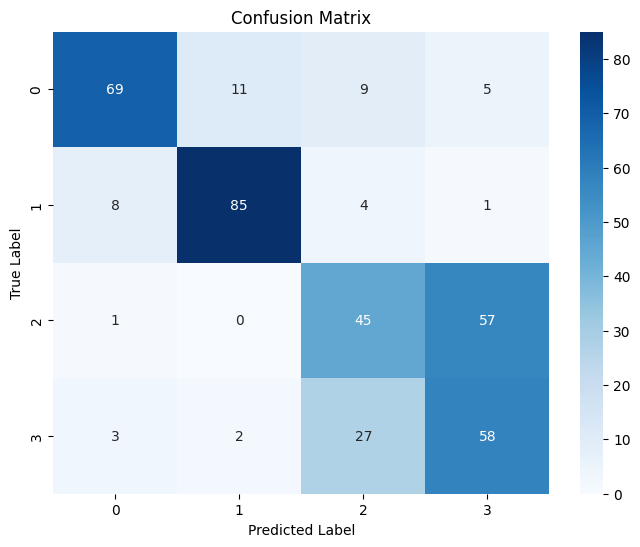

In [ ]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
print(classification_report(y_test, y_pred, target_names=[f'Class {i}' for i in range(NUM_CLASSES)]))

              precision    recall  f1-score   support

     Class 0       0.85      0.73      0.79        94
     Class 1       0.87      0.87      0.87        98
     Class 2       0.53      0.44      0.48       103
     Class 3       0.48      0.64      0.55        90

    accuracy                           0.67       385
   macro avg       0.68      0.67      0.67       385
weighted avg       0.68      0.67      0.67       385



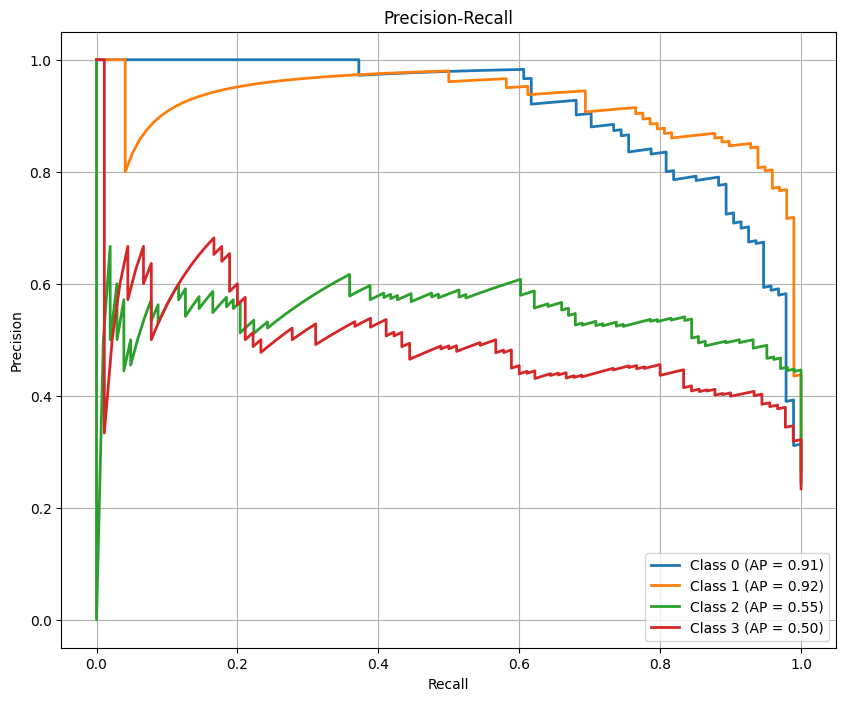

In [ ]:
y_test_bin = label_binarize(y_test, classes=range(NUM_CLASSES))

plt.figure(figsize=(10, 8))
for i in range(NUM_CLASSES):
    precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
    avg_precision = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
    plt.plot(recall, precision, lw=2, label=f'Class {i} (AP = {avg_precision:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall')
plt.legend()
plt.grid()
plt.show()

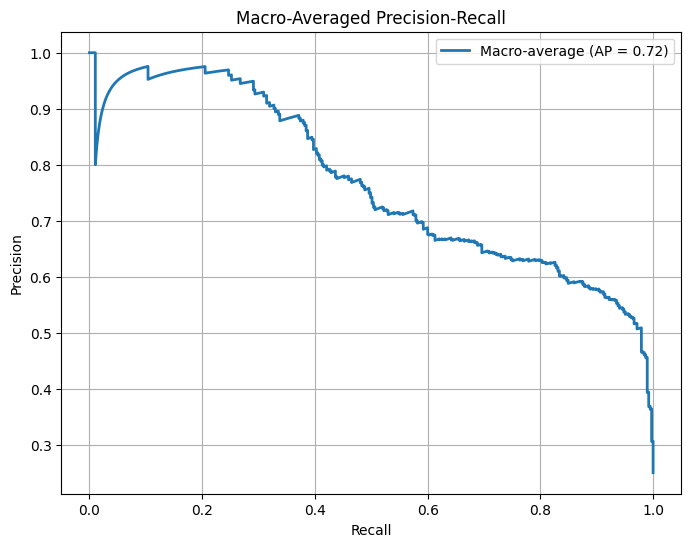

In [ ]:
precision_macro, recall_macro, _ = precision_recall_curve(
    y_test_bin.ravel(), y_pred_proba.ravel()
)
avg_precision_macro = average_precision_score(y_test_bin, y_pred_proba, average='macro')

plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro, lw=2,
         label=f'Macro-average (AP = {avg_precision_macro:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-Averaged Precision-Recall')
plt.legend()
plt.grid()
plt.show()